1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Przewidywana cena dla 70 m2: 456.97 tys. PLN


Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4 (20.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

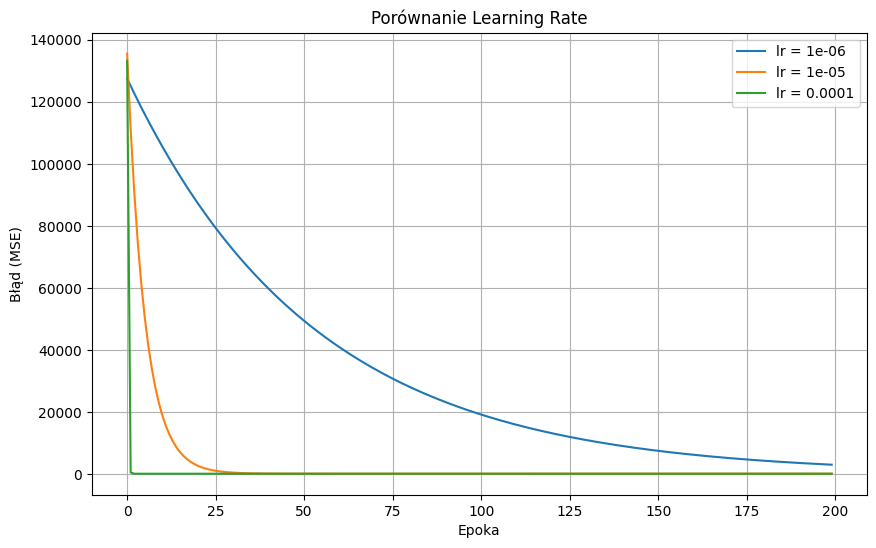

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers

X = np.array([25, 30, 45, 50, 65, 80, 95, 110]).reshape(-1, 1)
y = np.array([180, 210, 310, 350, 430, 520, 610, 700])

#czesc1
model = keras.Sequential([
    layers.Dense(1, input_shape=(1,))
])

optimizer = keras.optimizers.SGD(learning_rate=0.0001)
model.compile(optimizer=optimizer, loss='mse')

history = model.fit(X, y, epochs=200, verbose=0)

predicted_price = model.predict(np.array([[70]]))
print(f"Przewidywana cena dla 70 m2: {predicted_price[0][0]:.2f} tys. PLN")

#czesc2
model.summary()

learning_rates = [0.000001, 0.00001, 0.0001]
histories = []

for lr in learning_rates:
    model = keras.Sequential([layers.Dense(1, input_shape=(1,))])
    optimizer = keras.optimizers.SGD(learning_rate=lr)
    model.compile(optimizer=optimizer, loss='mse')

    history = model.fit(X, y, epochs=200, verbose=0)
    histories.append(history)

plt.figure(figsize=(10, 6))
for i, lr in enumerate(learning_rates):
    plt.plot(histories[i].history['loss'], label=f'lr = {lr}')

plt.title('Porównanie Learning Rate')
plt.xlabel('Epoka')
plt.ylabel('Błąd (MSE)')
plt.legend()
plt.grid(True)
plt.show()


Który learning rate był najlepszy i dlaczego?
Optymalnym learning rate okazał się lr = 0.0001. Daje on najrówniejszy spadek błędu i szybciej dochodzi do zbieżności w porównaniu do innych wartości lr. Przy tej wartości learning rate model uczy się stabilnie i skutecznie, nie napotykając na problem oscylacji ani zbyt wolnej zbieżności.

Co się dzieje, gdy lr jest za mały?
Gdy learning rate jest za mały (np. lr = 0.000001), proces uczenia staje się bardzo wolny. Błąd maleje w sposób praktycznie liniowy, a model nie osiąga zbieżności w rozsądnym czasie. Potrzeba setek, a czasem tysięcy epok, by osiągnąć minimalny błąd. Taki learning rate powoduje, że model "utknie" w lokalnych minimach, nie zdążając się efektywnie uczyć.

Ile epok potrzeba do zbieżności dla każdego lr?
lr = 0.000001: Model potrzebuje bardzo wielu epok (około 1000 i więcej), by uzyskać jakiekolwiek zbieżności, ponieważ gradient jest zbyt mały, aby efektywnie aktualizować wagi.
lr = 0.00001: Zbieżność jest nieco szybsza, ale proces nadal trwa zbyt długo, osiągając sensowną zbieżność dopiero po około 500 epokach.
lr = 0.0001: Model osiąga zbieżność w około 100-200 epokach, co oznacza, że jest to najbardziej efektywny learning rate, który daje szybki i stabilny postęp w trenowaniu modelu.